# Operation Duration Analysis

Loads all training parquet files **in parallel**, groups rows by contiguous OPERATION,
computes the duration of each operation segment, and plots histograms.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_DIR = "/home/yahia.shaaban/project/drilling data/train"
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files")

Found 1738 parquet files


## 1. Parallel Processing

Each worker processes one parquet file: reads `time` + `OPERATION` + `CODE`,
groups contiguous operations, computes duration per segment.

In [3]:
def process_file(fpath):
    """Process a single parquet file. Returns list of (code, operation, duration_seconds, num_rows)."""
    try:
        df = pd.read_parquet(fpath, columns=["time", "OPERATION", "CODE"])
    except Exception as e:
        return [], os.path.basename(fpath), str(e)

    df = df.dropna(subset=["OPERATION"])
    if len(df) == 0:
        return [], os.path.basename(fpath), "empty"

    # Ensure time is datetime
    if not pd.api.types.is_datetime64_any_dtype(df["time"]):
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

    # Group contiguous rows with same OPERATION
    df["op_group"] = (df["OPERATION"] != df["OPERATION"].shift()).cumsum()

    segments = []
    for _, group in df.groupby("op_group"):
        t_start = group["time"].iloc[0]
        t_end = group["time"].iloc[-1]
        if pd.isna(t_start) or pd.isna(t_end):
            # Fallback: use row count as proxy (1 row ≈ 1 second for 1Hz data)
            duration = len(group)
        else:
            duration = (t_end - t_start).total_seconds()

        segments.append({
            "code": str(group["CODE"].iloc[0]),
            "operation": str(group["OPERATION"].iloc[0])[:150],
            "duration_sec": duration,
            "num_rows": len(group),
            "file": os.path.basename(fpath),
        })

    return segments, os.path.basename(fpath), None

In [4]:
%%time

all_segments = []
errors = []
N_WORKERS = 16

with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(process_file, f): f for f in parquet_files}
    done = 0
    for future in as_completed(futures):
        segments, fname, err = future.result()
        if err:
            errors.append((fname, err))
        else:
            all_segments.extend(segments)
        done += 1
        if done % 200 == 0:
            print(f"  Processed {done}/{len(parquet_files)} files, {len(all_segments)} segments so far...")

print(f"\nDone: {len(all_segments)} segments from {len(parquet_files) - len(errors)} files")
if errors:
    print(f"Errors: {len(errors)} files skipped")
    for fname, err in errors[:5]:
        print(f"  {fname}: {err}")

  Processed 200/1738 files, 30153 segments so far...
  Processed 400/1738 files, 57934 segments so far...
  Processed 600/1738 files, 96575 segments so far...
  Processed 800/1738 files, 129472 segments so far...
  Processed 1000/1738 files, 159737 segments so far...
  Processed 1200/1738 files, 191419 segments so far...
  Processed 1400/1738 files, 220547 segments so far...
  Processed 1600/1738 files, 254720 segments so far...

Done: 279681 segments from 1726 files
Errors: 12 files skipped
  Sensors_BB-1302_WORKOVER_Time_Drilling_Log.parquet: empty
  Sensors_BB-1928_12_25in_BB-1928.parquet: empty
  Sensors_BB-1931_12_25in_BB-1931.parquet: empty
  Sensors_BB-1931_16in_BB-1931.parquet: empty
  Sensors_BB-1931_26in_BB-1931.parquet: empty
CPU times: user 1.11 s, sys: 292 ms, total: 1.4 s
Wall time: 2min 2s


In [5]:
df_seg = pd.DataFrame(all_segments)
df_seg["duration_min"] = df_seg["duration_sec"] / 60
df_seg["duration_hr"] = df_seg["duration_sec"] / 3600

print(f"Total segments: {len(df_seg):,}")
print(f"Unique codes: {df_seg['code'].nunique()}")
print(f"Unique operations: {df_seg['operation'].nunique()}")
print(f"\nDuration stats (minutes):")
print(df_seg["duration_min"].describe())

Total segments: 279,681
Unique codes: 61
Unique operations: 201877

Duration stats (minutes):
count    279681.000000
mean        135.353845
std         177.032707
min           0.000000
25%          29.983333
50%          59.983333
75%         149.983333
max        3569.983333
Name: duration_min, dtype: float64


## 2. Overall Duration Histogram

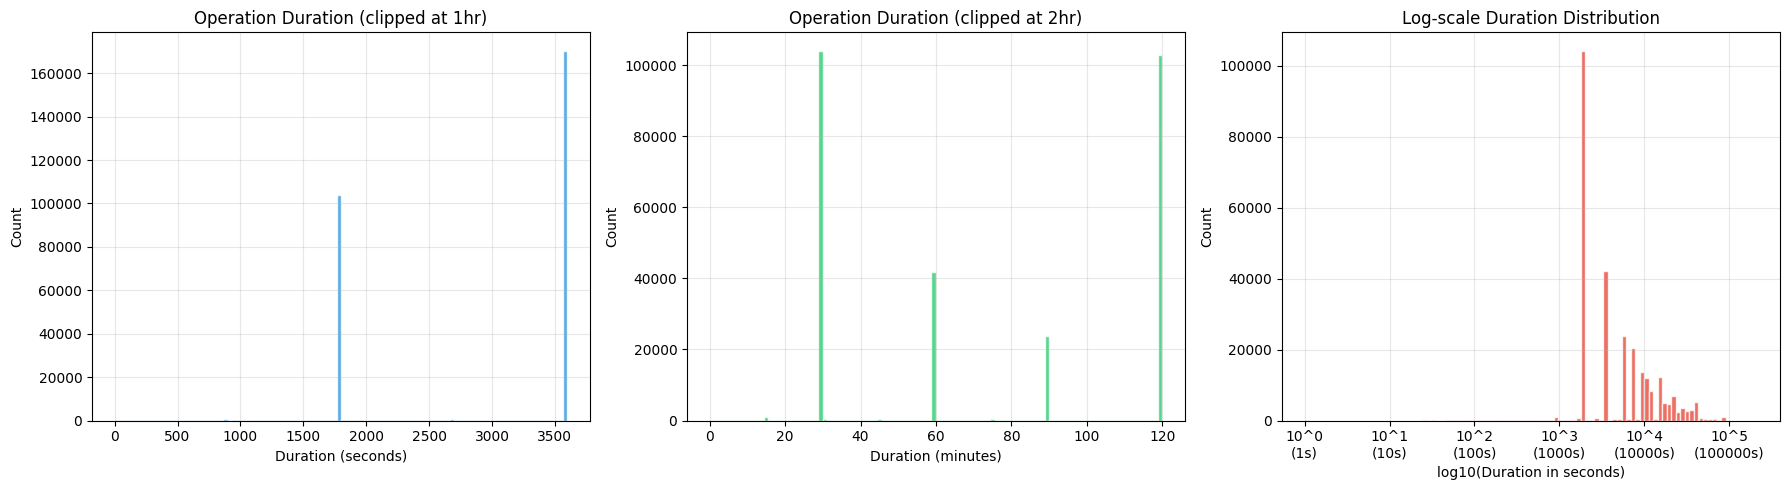

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram in seconds (clipped)
axes[0].hist(df_seg["duration_sec"].clip(upper=3600), bins=100, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Operation Duration (clipped at 1hr)")
axes[0].grid(True, alpha=0.3)

# Histogram in minutes (clipped)
axes[1].hist(df_seg["duration_min"].clip(upper=120), bins=100, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count")
axes[1].set_title("Operation Duration (clipped at 2hr)")
axes[1].grid(True, alpha=0.3)

# Log-scale histogram
axes[2].hist(np.log10(df_seg["duration_sec"].clip(lower=1)), bins=100, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[2].set_xlabel("log10(Duration in seconds)")
axes[2].set_ylabel("Count")
axes[2].set_title("Log-scale Duration Distribution")
xticks = [0, 1, 2, 3, 4, 5]
axes[2].set_xticks(xticks)
axes[2].set_xticklabels([f"10^{x}\n({10**x}s)" for x in xticks])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("operation_durations_overall.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Duration by Operation Code

In [7]:
# Top codes by frequency
top_codes = df_seg["code"].value_counts().head(15)
print("Segment count per code:")
print(top_codes)
print(f"\nMedian duration (minutes) per code:")
print(df_seg.groupby("code")["duration_min"].median().sort_values(ascending=False).head(15))

Segment count per code:
code
TRIP     52292
SAFE     36721
DRILL    28674
CM       24454
CSG      21390
CIRC     17112
CMT      11382
BOP      11382
RIGMT    10840
LOG       9206
FISH      9005
WLHD      6937
WAIT      5386
SRFEQ     4593
WL        3960
Name: count, dtype: int64

Median duration (minutes) per code:
code
DRILOUT    678.133333
DRIL       404.983333
21INRC     239.983333
WAIT       206.000000
LOCMOV     179.983333
TS         179.983333
WAT        179.983333
BOB        179.983333
MOB        149.983333
PUMP       149.983333
DRILL      135.708333
CT         119.983333
LOG        119.983333
WOW        119.983333
REDRL      119.983333
Name: duration_min, dtype: float64


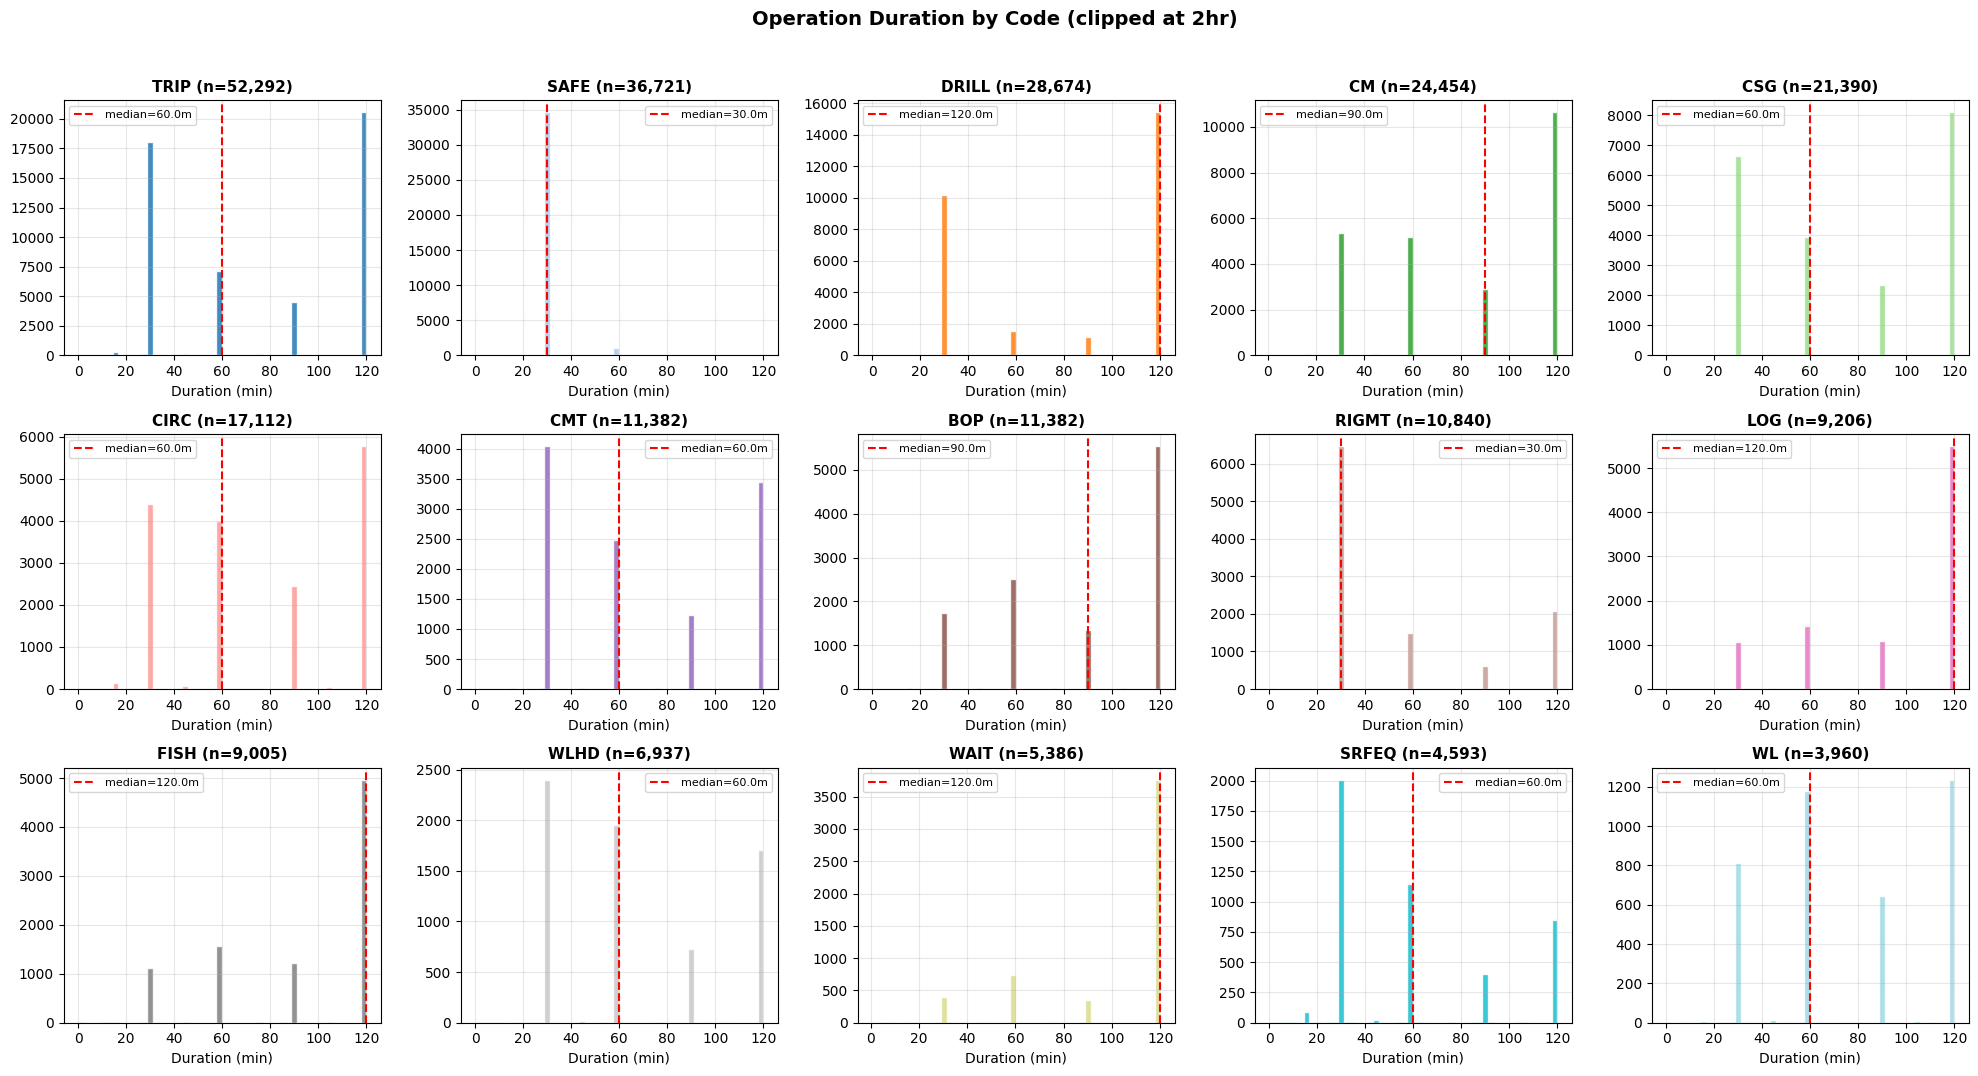

In [8]:
codes_to_plot = top_codes.index.tolist()
n_codes = len(codes_to_plot)
ncols = 5
nrows = (n_codes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, n_codes))

for i, code in enumerate(codes_to_plot):
    subset = df_seg[df_seg["code"] == code]["duration_min"].clip(upper=120)
    axes[i].hist(subset, bins=50, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(f"{code} (n={len(subset):,})", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Duration (min)")
    median_val = subset.median()
    axes[i].axvline(median_val, color="red", linestyle="--", linewidth=1.5, label=f"median={median_val:.1f}m")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Operation Duration by Code (clipped at 2hr)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("operation_durations_by_code.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Box Plot: Duration by Code

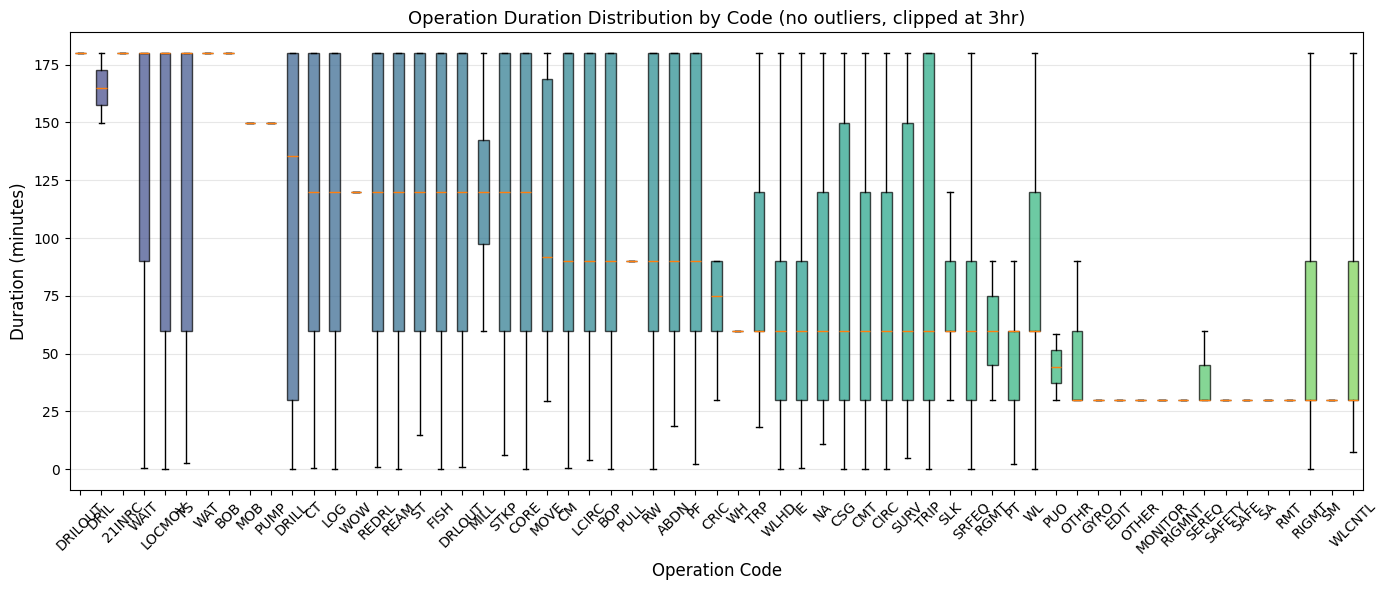

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Order by median duration
order = df_seg.groupby("code")["duration_min"].median().sort_values(ascending=False).index
data_to_plot = [df_seg[df_seg["code"] == c]["duration_min"].clip(upper=180).values for c in order]

bp = ax.boxplot(data_to_plot, labels=order, patch_artist=True, showfliers=False)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Duration (minutes)", fontsize=12)
ax.set_xlabel("Operation Code", fontsize=12)
ax.set_title("Operation Duration Distribution by Code (no outliers, clipped at 3hr)", fontsize=13)
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("operation_durations_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Number of Rows (Timesteps) per Segment

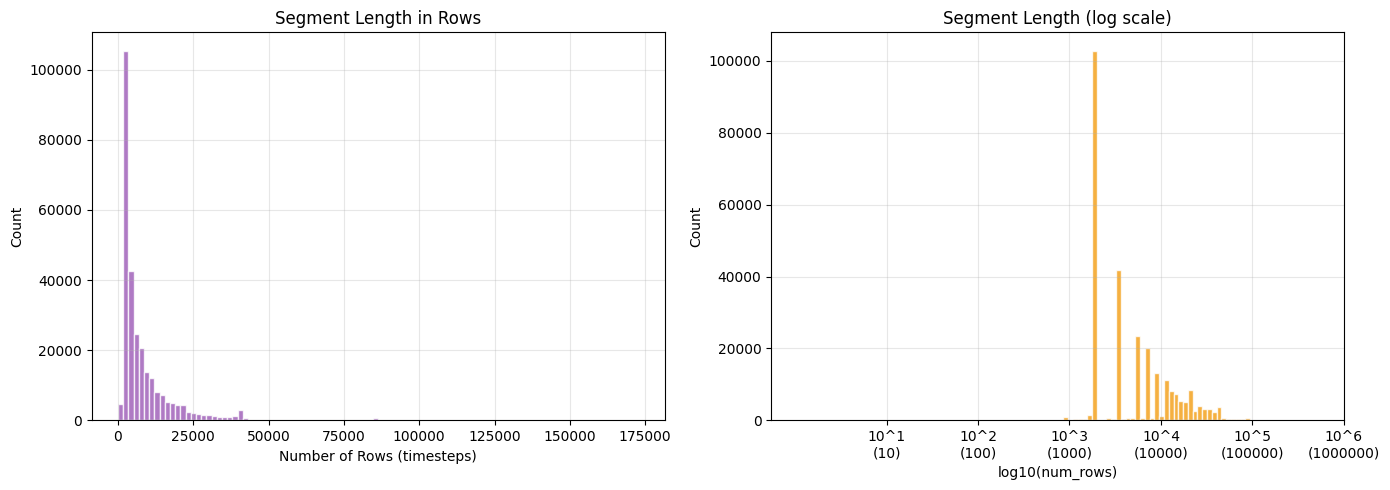

Row count stats:
count    279681.000000
mean       8050.574143
std       10499.376247
min           1.000000
25%        1800.000000
50%        3600.000000
75%        9000.000000
max      172800.000000
Name: num_rows, dtype: float64

Segments with >65536 rows (window_size): 1374 (0.5%)
Segments with <512 rows (subsample):      764 (0.3%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_seg["num_rows"].clip(upper=200000), bins=100, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Number of Rows (timesteps)")
axes[0].set_ylabel("Count")
axes[0].set_title("Segment Length in Rows")
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log10(df_seg["num_rows"].clip(lower=1)), bins=100, color="#f39c12", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log10(num_rows)")
axes[1].set_ylabel("Count")
axes[1].set_title("Segment Length (log scale)")
xticks = [1, 2, 3, 4, 5, 6]
axes[1].set_xticks(xticks)
axes[1].set_xticklabels([f"10^{x}\n({10**x})" for x in xticks])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("segment_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Row count stats:")
print(df_seg["num_rows"].describe())
print(f"\nSegments with >65536 rows (window_size): {(df_seg['num_rows'] > 65536).sum()} ({(df_seg['num_rows'] > 65536).mean()*100:.1f}%)")
print(f"Segments with <512 rows (subsample):      {(df_seg['num_rows'] < 512).sum()} ({(df_seg['num_rows'] < 512).mean()*100:.1f}%)")

## 6. Summary Table

In [11]:
summary = df_seg.groupby("code").agg(
    count=("duration_sec", "count"),
    mean_duration_min=("duration_min", "mean"),
    median_duration_min=("duration_min", "median"),
    std_duration_min=("duration_min", "std"),
    mean_rows=("num_rows", "mean"),
    median_rows=("num_rows", "median"),
).sort_values("count", ascending=False)

summary = summary.round(1)
print(summary.to_string())

         count  mean_duration_min  median_duration_min  std_duration_min  mean_rows  median_rows
code                                                                                            
TRIP     52292              125.0                 60.0             134.9     7452.8       3600.0
SAFE     36721               32.7                 30.0              35.8     1918.1       1800.0
DRILL    28674              248.5                135.7             281.8    14762.3       7200.0
CM       24454              154.3                 90.0             177.3     9188.6       5400.0
CSG      21390              129.5                 60.0             152.2     7718.7       3600.0
CIRC     17112               99.3                 60.0              87.4     5920.1       3600.0
BOP      11382              135.4                 90.0             121.4     8068.9       5400.0
CMT      11382              110.1                 60.0             133.8     6567.2       3600.0
RIGMT    10840               8

## 7. Sensor Data Discontinuities & Gap Analysis

For each parquet file, compute time gaps between consecutive rows.
A "discontinuity" is any gap larger than the expected sampling interval (1 second for 1Hz).
This runs in parallel across all files.

In [12]:
def analyze_gaps(fpath):
    """Analyze time gaps and NaN discontinuities in a single parquet file."""
    try:
        df = pd.read_parquet(fpath, columns=["time"] + [
            "rot_vel", "stand_pressure", "wob", "torque", "flow_rate",
            "flow_out_perc", "bit_depth", "block_pos", "hook_load",
            "hole_depth", "tank_vol",
        ])
    except Exception as e:
        return None, os.path.basename(fpath), str(e)

    fname = os.path.basename(fpath)
    n_rows = len(df)

    if n_rows < 2:
        return None, fname, "too few rows"

    # --- Time gaps ---
    if not pd.api.types.is_datetime64_any_dtype(df["time"]):
        df["time"] = pd.to_datetime(df["time"], errors="coerce")

    time_diffs = df["time"].diff().dt.total_seconds().dropna()

    # Gaps > 2 seconds are discontinuities (allowing 1s tolerance for 1Hz data)
    gap_threshold = 2.0
    gaps = time_diffs[time_diffs > gap_threshold]

    # --- NaN analysis per sensor ---
    sensor_cols = ["rot_vel", "stand_pressure", "wob", "torque", "flow_rate",
                   "flow_out_perc", "bit_depth", "block_pos", "hook_load",
                   "hole_depth", "tank_vol"]
    nan_counts = {col: df[col].isna().sum() for col in sensor_cols}
    total_nan_rows = df[sensor_cols].isna().any(axis=1).sum()

    # --- NaN streaks (contiguous NaN blocks) ---
    any_nan = df[sensor_cols].isna().any(axis=1)
    nan_changed = any_nan != any_nan.shift()
    nan_groups = nan_changed.cumsum()
    nan_streaks = []
    for gid, grp in any_nan.groupby(nan_groups):
        if grp.iloc[0]:  # this is a NaN block
            nan_streaks.append(len(grp))

    return {
        "file": fname,
        "n_rows": n_rows,
        "n_time_gaps": len(gaps),
        "gap_sizes_sec": gaps.values.tolist(),
        "median_sampling_sec": time_diffs.median(),
        "nan_per_sensor": nan_counts,
        "total_nan_rows": total_nan_rows,
        "nan_frac": total_nan_rows / n_rows,
        "nan_streak_lengths": nan_streaks,
    }, fname, None

In [13]:
%%time

gap_results = []
gap_errors = []

with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(analyze_gaps, f): f for f in parquet_files}
    done = 0
    for future in as_completed(futures):
        result, fname, err = future.result()
        if err:
            gap_errors.append((fname, err))
        elif result is not None:
            gap_results.append(result)
        done += 1
        if done % 200 == 0:
            print(f"  Analyzed {done}/{len(parquet_files)} files...")

print(f"\nDone: {len(gap_results)} files analyzed, {len(gap_errors)} errors")

  Analyzed 200/1738 files...
  Analyzed 400/1738 files...
  Analyzed 600/1738 files...
  Analyzed 800/1738 files...
  Analyzed 1000/1738 files...
  Analyzed 1200/1738 files...
  Analyzed 1400/1738 files...
  Analyzed 1600/1738 files...

Done: 1738 files analyzed, 0 errors
CPU times: user 932 ms, sys: 336 ms, total: 1.27 s
Wall time: 54.8 s


In [14]:
# Aggregate all gap sizes across files
all_gap_sizes = []
for r in gap_results:
    all_gap_sizes.extend(r["gap_sizes_sec"])

all_gap_sizes = np.array(all_gap_sizes)
files_with_gaps = sum(1 for r in gap_results if r["n_time_gaps"] > 0)
total_gaps = len(all_gap_sizes)

print(f"=== TIME GAP SUMMARY ===")
print(f"Files with discontinuities: {files_with_gaps}/{len(gap_results)} ({files_with_gaps/len(gap_results)*100:.1f}%)")
print(f"Total gaps found: {total_gaps:,}")
print(f"\nGap size stats (seconds):")
if total_gaps > 0:
    print(f"  Min:    {all_gap_sizes.min():.1f}s")
    print(f"  Median: {np.median(all_gap_sizes):.1f}s")
    print(f"  Mean:   {np.mean(all_gap_sizes):.1f}s")
    print(f"  P95:    {np.percentile(all_gap_sizes, 95):.1f}s")
    print(f"  P99:    {np.percentile(all_gap_sizes, 99):.1f}s")
    print(f"  Max:    {all_gap_sizes.max():.1f}s ({all_gap_sizes.max()/3600:.1f}hr)")

# Gaps per file distribution
gaps_per_file = [r["n_time_gaps"] for r in gap_results]
print(f"\nGaps per file: mean={np.mean(gaps_per_file):.1f}, median={np.median(gaps_per_file):.0f}, max={np.max(gaps_per_file)}")

=== TIME GAP SUMMARY ===
Files with discontinuities: 1680/1738 (96.7%)
Total gaps found: 56,165

Gap size stats (seconds):
  Min:    61.0s
  Median: 88.0s
  Mean:   6701.9s
  P95:    3867.8s
  P99:    24488.0s
  Max:    289056310.0s (80293.4hr)

Gaps per file: mean=32.3, median=11, max=3293


### 7a. Gap Size Distribution

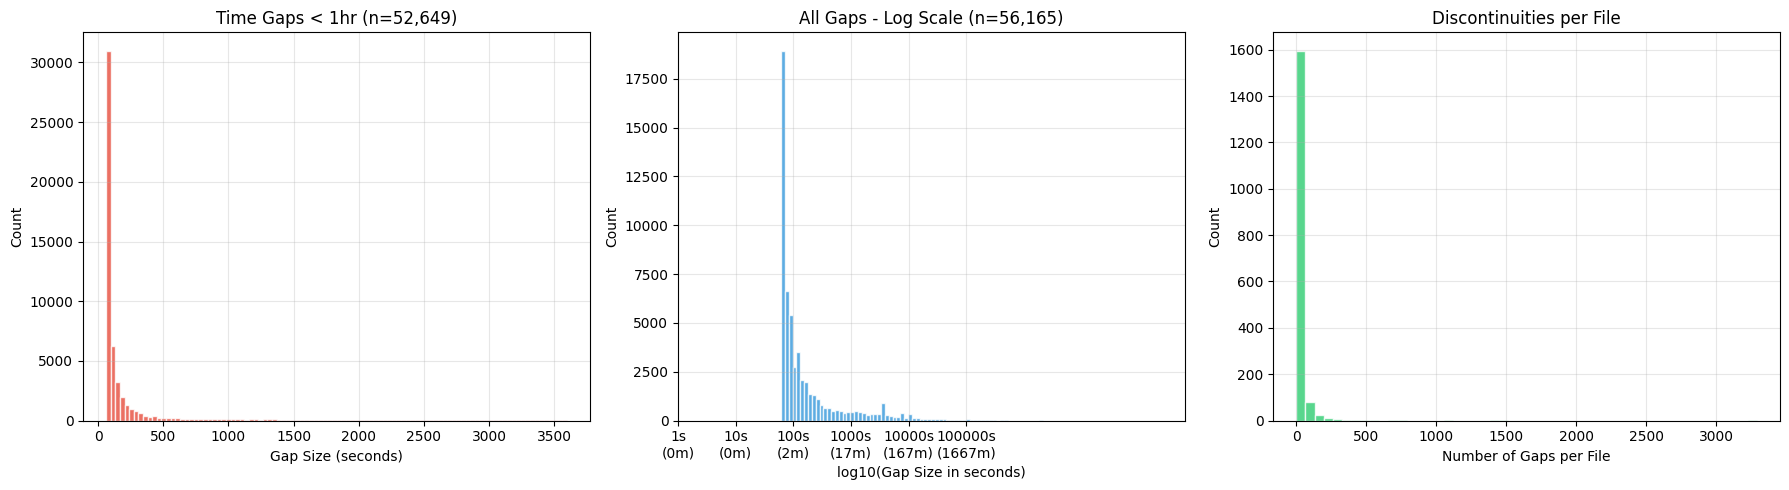


Gap size buckets:
  Bucket                  Count      Pct
  --------------------------------------
  2s - 10s                    0     0.0%
  10s - 1min                  0     0.0%
  1min - 10min           48,066    85.6%
  10min - 1hr             4,583     8.2%
  1hr - 6hr               2,892     5.1%
  > 6hr                     624     1.1%


In [15]:
if total_gaps > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Raw gap distribution (clipped)
    axes[0].hist(all_gap_sizes[all_gap_sizes < 3600], bins=100, color="#e74c3c", edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Gap Size (seconds)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Time Gaps < 1hr (n={np.sum(all_gap_sizes < 3600):,})")
    axes[0].grid(True, alpha=0.3)

    # Log-scale gap distribution
    axes[1].hist(np.log10(all_gap_sizes.clip(min=1)), bins=100, color="#3498db", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("log10(Gap Size in seconds)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"All Gaps - Log Scale (n={total_gaps:,})")
    xticks = [0, 1, 2, 3, 4, 5]
    axes[1].set_xticks(xticks)
    axes[1].set_xticklabels([f"{10**x}s\n({10**x/60:.0f}m)" for x in xticks])
    axes[1].grid(True, alpha=0.3)

    # Gaps per file
    axes[2].hist(gaps_per_file, bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[2].set_xlabel("Number of Gaps per File")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Discontinuities per File")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("gap_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Bucketed gap analysis
    buckets = [
        ("2s - 10s", 2, 10),
        ("10s - 1min", 10, 60),
        ("1min - 10min", 60, 600),
        ("10min - 1hr", 600, 3600),
        ("1hr - 6hr", 3600, 21600),
        ("> 6hr", 21600, float("inf")),
    ]
    print("\nGap size buckets:")
    print(f"  {'Bucket':<20s} {'Count':>8s} {'Pct':>8s}")
    print("  " + "-" * 38)
    for label, lo, hi in buckets:
        count = np.sum((all_gap_sizes >= lo) & (all_gap_sizes < hi))
        pct = count / total_gaps * 100
        print(f"  {label:<20s} {count:>8,d} {pct:>7.1f}%")
else:
    print("No gaps found!")

### 7b. NaN / Missing Sensor Data Analysis

In [16]:
# NaN fraction per file
nan_fracs = [r["nan_frac"] for r in gap_results]
files_with_nans = sum(1 for f in nan_fracs if f > 0)

print(f"=== NaN SUMMARY ===")
print(f"Files with any NaN: {files_with_nans}/{len(gap_results)} ({files_with_nans/len(gap_results)*100:.1f}%)")
print(f"\nNaN fraction per file:")
print(f"  Mean:   {np.mean(nan_fracs)*100:.2f}%")
print(f"  Median: {np.median(nan_fracs)*100:.2f}%")
print(f"  P90:    {np.percentile(nan_fracs, 90)*100:.2f}%")
print(f"  Max:    {np.max(nan_fracs)*100:.2f}%")

# NaN per sensor channel (aggregate)
sensor_cols = ["rot_vel", "stand_pressure", "wob", "torque", "flow_rate",
               "flow_out_perc", "bit_depth", "block_pos", "hook_load",
               "hole_depth", "tank_vol"]

total_rows_all = sum(r["n_rows"] for r in gap_results)
sensor_nan_totals = {col: 0 for col in sensor_cols}
for r in gap_results:
    for col in sensor_cols:
        sensor_nan_totals[col] += r["nan_per_sensor"][col]

print(f"\nNaN rate per sensor channel (across all {total_rows_all:,} rows):")
print(f"  {'Channel':<20s} {'NaN Count':>12s} {'NaN %':>8s}")
print("  " + "-" * 42)
for col in sorted(sensor_nan_totals, key=lambda c: -sensor_nan_totals[c]):
    cnt = sensor_nan_totals[col]
    pct = cnt / total_rows_all * 100
    print(f"  {col:<20s} {cnt:>12,d} {pct:>7.2f}%")

=== NaN SUMMARY ===
Files with any NaN: 1734/1738 (99.8%)

NaN fraction per file:
  Mean:   3.60%
  Median: 0.04%
  P90:    4.22%
  Max:    100.00%

NaN rate per sensor channel (across all 2,556,387,651 rows):
  Channel                 NaN Count    NaN %
  ------------------------------------------
  torque                 32,772,949    1.28%
  flow_rate              22,325,264    0.87%
  rot_vel                17,385,580    0.68%
  bit_depth              13,892,998    0.54%
  wob                    12,276,769    0.48%
  block_pos               7,307,072    0.29%
  stand_pressure          7,034,092    0.28%
  hole_depth              6,575,385    0.26%
  tank_vol                5,218,139    0.20%
  hook_load               4,957,727    0.19%
  flow_out_perc           4,490,505    0.18%


NaN streak stats (rows):
  Total streaks: 28,584
  Median length: 1 rows
  Mean length:   3111 rows
  P95 length:    1274 rows
  Max length:    4,805,668 rows (1334.9 hr at 1Hz)


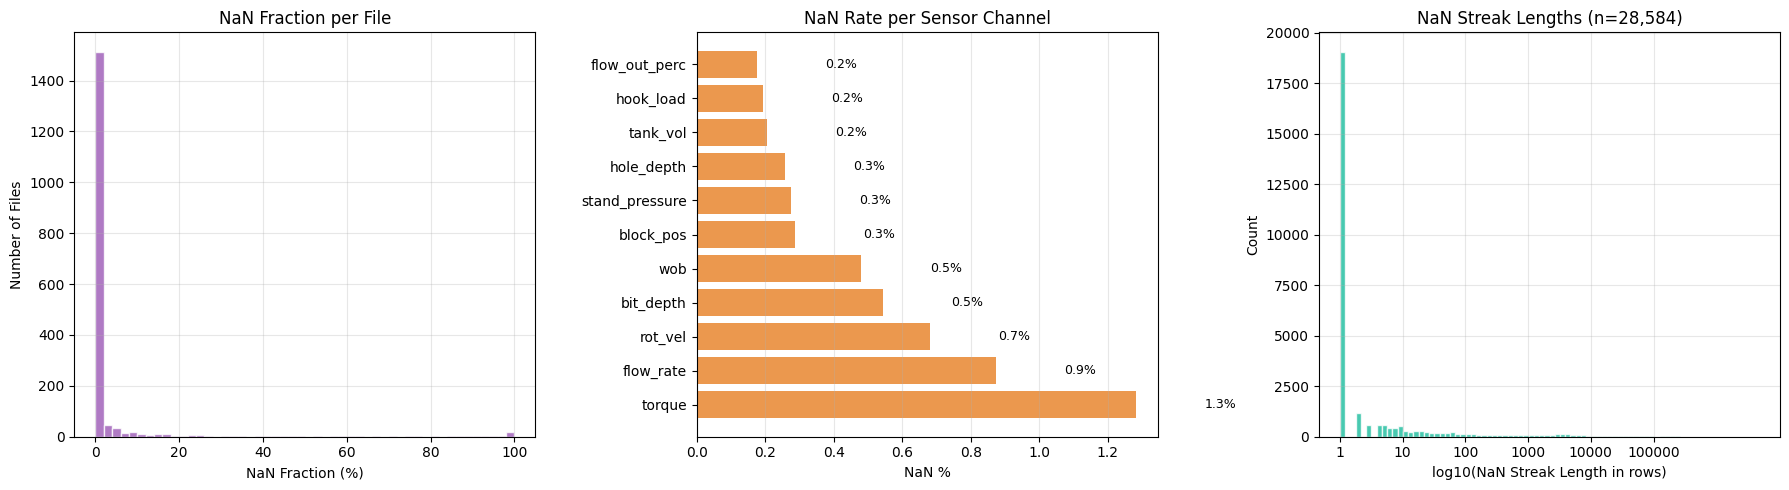

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NaN fraction per file
axes[0].hist([f * 100 for f in nan_fracs], bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("NaN Fraction (%)")
axes[0].set_ylabel("Number of Files")
axes[0].set_title("NaN Fraction per File")
axes[0].grid(True, alpha=0.3)

# NaN per sensor channel (bar chart)
sorted_cols = sorted(sensor_nan_totals, key=lambda c: -sensor_nan_totals[c])
nan_pcts = [sensor_nan_totals[c] / total_rows_all * 100 for c in sorted_cols]
bars = axes[1].barh(sorted_cols, nan_pcts, color="#e67e22", alpha=0.8)
axes[1].set_xlabel("NaN %")
axes[1].set_title("NaN Rate per Sensor Channel")
axes[1].grid(True, alpha=0.3, axis="x")
for bar, pct in zip(bars, nan_pcts):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{pct:.1f}%", va="center", fontsize=9)

# NaN streak lengths (how long are contiguous NaN blocks?)
all_nan_streaks = []
for r in gap_results:
    all_nan_streaks.extend(r["nan_streak_lengths"])

if all_nan_streaks:
    all_nan_streaks = np.array(all_nan_streaks)
    axes[2].hist(np.log10(all_nan_streaks.clip(min=1)), bins=80, color="#1abc9c", edgecolor="white", alpha=0.8)
    axes[2].set_xlabel("log10(NaN Streak Length in rows)")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"NaN Streak Lengths (n={len(all_nan_streaks):,})")
    xticks = [0, 1, 2, 3, 4, 5]
    axes[2].set_xticks(xticks)
    axes[2].set_xticklabels([f"{10**x}" for x in xticks])
    axes[2].grid(True, alpha=0.3)

    print(f"NaN streak stats (rows):")
    print(f"  Total streaks: {len(all_nan_streaks):,}")
    print(f"  Median length: {np.median(all_nan_streaks):.0f} rows")
    print(f"  Mean length:   {np.mean(all_nan_streaks):.0f} rows")
    print(f"  P95 length:    {np.percentile(all_nan_streaks, 95):.0f} rows")
    print(f"  Max length:    {np.max(all_nan_streaks):,} rows ({np.max(all_nan_streaks)/3600:.1f} hr at 1Hz)")

plt.tight_layout()
plt.savefig("nan_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### 7c. Sampling Rate Analysis

Verify actual sampling rate — is the data truly 1Hz or does it vary?

Most common sampling intervals:
  1.0s → 1738 files (100.0%)


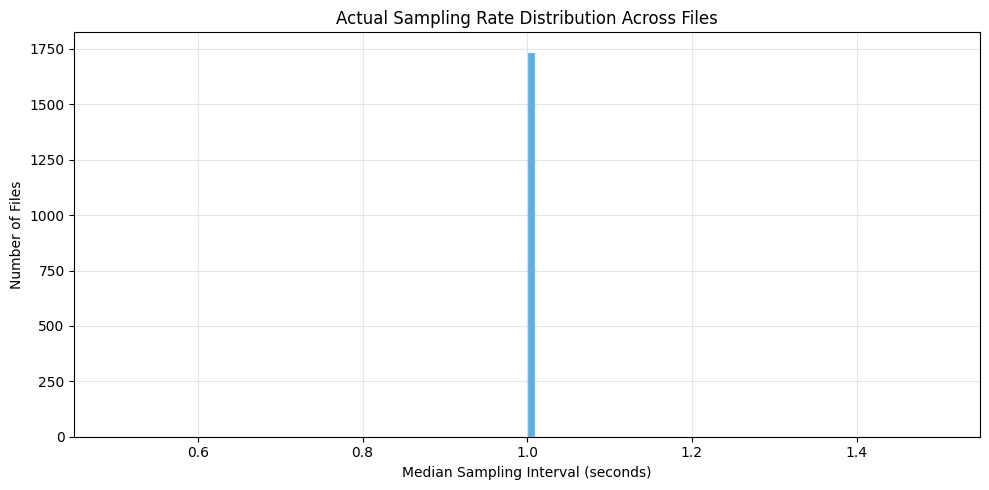

In [18]:
sampling_rates = [r["median_sampling_sec"] for r in gap_results if r["median_sampling_sec"] is not None and not np.isnan(r["median_sampling_sec"])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sampling_rates, bins=100, color="#3498db", edgecolor="white", alpha=0.8)
ax.set_xlabel("Median Sampling Interval (seconds)")
ax.set_ylabel("Number of Files")
ax.set_title("Actual Sampling Rate Distribution Across Files")
ax.grid(True, alpha=0.3)

# Annotate common rates
from collections import Counter
rounded = Counter(round(s, 1) for s in sampling_rates)
print("Most common sampling intervals:")
for interval, count in rounded.most_common(10):
    print(f"  {interval}s → {count} files ({count/len(sampling_rates)*100:.1f}%)")

plt.tight_layout()
plt.savefig("sampling_rate.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. OPERATION Text Quality Analysis

Sample unique `OPERATION` strings and quantify common text-quality issues:

- **Heavy abbreviations**: "PJSM", "R/U", "N/U", "P/T", "L/D", "POOH", "RIH", "M/U", "CONT'D"
- **Inconsistent casing/spelling**: "CONT'D" vs "COUNT'D", "w/" vs "with"
- **Mixed numeric formats**: `5½"`, `5 1/2"`, `5-1/2"`
- **Telegraphic style missing context**: "INSTALL WEAR BUSHING" vs "Installed wear bushing on the wellhead"
- **Cryptic codes inline**: `[R-1]`, `[R-2]`

In [ ]:
import re
from collections import Counter

# Collect unique OPERATION values from all training files
ops_all = set()
for fpath in parquet_files:
    df_tmp = pd.read_parquet(fpath, columns=["OPERATION"])
    ops_all.update(df_tmp["OPERATION"].dropna().unique())

ops_list = sorted(ops_all)
N = len(ops_list)
print(f"Total unique OPERATION strings: {N}\n")

# --- 1. Leading / trailing whitespace ---
ws = [o for o in ops_list if o != o.strip()]
print(f"1. Leading/trailing whitespace: {len(ws):,} / {N:,} ({100*len(ws)/N:.1f}%)")

# --- 2. Trailing period inconsistency ---
with_period = [o for o in ops_list if o.strip().endswith('.')]
print(f"2. Ends with period: {len(with_period):,} ({100*len(with_period)/N:.1f}%)  |  "
      f"Without: {N - len(with_period):,} ({100*(N - len(with_period))/N:.1f}%)")

# --- 3. Multi-line entries (embedded newlines) ---
multiline = [o for o in ops_list if '\n' in o]
print(f"3. Multi-line entries: {len(multiline):,} ({100*len(multiline)/N:.1f}%)  "
      f"avg lines={np.mean([o.count(chr(10))+1 for o in multiline]):.1f}  "
      f"max={max((o.count(chr(10))+1 for o in multiline), default=0)}")

# --- 4. ** sub-bullet notes ---
stars = [o for o in ops_list if '**' in o]
print(f"4. Contains ** sub-notes: {len(stars):,} ({100*len(stars)/N:.1f}%)")

# --- 5. [R-N] inline reference codes ---
refs = [o for o in ops_list if re.search(r'\[R-\d+\]', o)]
print(f"5. Contains [R-N] references: {len(refs):,} ({100*len(refs)/N:.1f}%)")

# --- 6. Case inconsistency ---
all_upper = [o for o in ops_list if o == o.upper()]
print(f"6. Case: ALL CAPS={len(all_upper):,} ({100*len(all_upper)/N:.1f}%)  "
      f"Mixed={N - len(all_upper):,} ({100*(N - len(all_upper))/N:.1f}%)")

# --- 7. Double/multiple spaces ---
dbl = [o for o in ops_list if '  ' in o]
print(f"7. Double/multiple spaces: {len(dbl):,} ({100*len(dbl)/N:.1f}%)")

# --- 8. Mixed numeric formats  (e.g. 5½  vs  5 1/2  vs  5-1/2) ---
unicode_frac = [o for o in ops_list if re.search(r'[\u00BC-\u00BE\u2150-\u215E\u00BD]', o)]
text_frac    = [o for o in ops_list if re.search(r'\d+\s+\d+/\d+', o)]
dash_frac    = [o for o in ops_list if re.search(r'\d+-\d+/\d+', o)]
print(f"8. Numeric formats  unicode-frac={len(unicode_frac):,}  "
      f"space-frac(5 1/2)={len(text_frac):,}  "
      f"dash-frac(5-1/2)={len(dash_frac):,}")

# --- 9. Heavy abbreviations frequency ---
abbrevs = Counter()
for o in ops_list:
    up = o.upper()
    for tag in ["PJSM", "RIH", "POOH", "BOP", "WOC"]:
        if tag in up: abbrevs[tag] += 1
    for tag, pattern in [("W/", "W/"), ("M/U", "M/U"), ("P/U", "P/U"),
                         ("R/U", "R/U"), ("L/D", "L/D"), ("N/U", "N/U"),
                         ("N/D", "N/D"), ("B/O", "B/O"), ("P/T", "P/T")]:
        if pattern in up: abbrevs[tag] += 1
    if "CONT'D" in up or "CONT." in up or "CONTINUED" in up:
        abbrevs["CONT'D / CONT. / CONTINUED"] += 1

print("\n9. Abbreviation frequency:")
for k, v in abbrevs.most_common():
    print(f"   {k:30s} {v:>5,}  ({100*v/N:.1f}%)")

# --- 10. String length distribution ---
lengths = [len(o) for o in ops_list]
print(f"\n10. String length: min={min(lengths)}  median={int(np.median(lengths))}  "
      f"mean={np.mean(lengths):.0f}  max={max(lengths)}")
print(f"    Very short (<10 chars): {sum(1 for l in lengths if l < 10)}")
print(f"    Very long  (>500 chars): {sum(1 for l in lengths if l > 500)}")

### 8a. Recommended Cleaning Pipeline

| Step | Action | Target | Regex / Method |
|------|--------|--------|----------------|
| 1 | Strip whitespace | 15.8% of values | `.strip()` |
| 2 | Remove `[R-N]` tags | ~5% | `re.sub(r'\[R-\d+\]', '', s)` |
| 3 | Extract primary operation | 18% multi-line | Keep first line; drop `**` / `OFFLINE:` / `NOTE:` blocks |
| 4 | Normalize case | 12% mixed | `.upper()` |
| 5 | Collapse multiple spaces | 13% | `re.sub(r'\s+', ' ', s).strip()` |
| 6 | Standardize trailing punctuation | 61% with `.` vs 39% without | Strip trailing `.` |
| 7 | Normalize fractions | 3 competing formats | Map `½` → `1/2`, `5-1/2` → `5 1/2` |
| 8 | Standardize abbreviations | CONT'D / CONT. / CONTINUED | Pick one canonical form per abbreviation |